# DBSCAN 예시

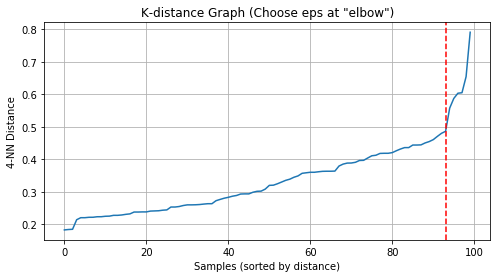

클러스터 라벨 분포: (array([-1,  0,  1], dtype=int64), array([ 4, 90,  6], dtype=int64))


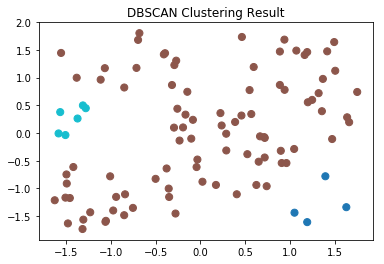

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# 1. 데이터 준비 및 표준화
# 예시 데이터: 100개 샘플, 2차원
# X = np.random.rand(100, 2)
X_scaled = StandardScaler().fit_transform(X)

# 2. k-거리 계산 (min_samples 기준, 예: 차원수*2 또는 4~5)
min_samples = 4 # 차원수*2, 4번째로 가까운 이웃까지
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, min_samples-1])

# 3. k-거리 그래프 시각화: elbow(엘보, knee) 직접 관찰
plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.xlabel('Samples (sorted by distance)')
plt.ylabel(f'{min_samples}-NN Distance')
plt.title('K-distance Graph (Choose eps at "elbow")')
plt.grid(True)
plt.axvline(x=93, color='r', linestyle='--')
plt.show()

# 4. elbow(엘보) 지점의 y축 값(거리값)을 eps로 사용
#그래프가 완만하게 증가하다가 어느 순간 급격히 증가(꺾임, elbow, knee point)가 나타나는 지점
eps = k_distances[93]  # <<== 반드시 그래프 상에서 적절한 값으로 직접 수정

# 5. DBSCAN 적용
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X_scaled)

print("클러스터 라벨 분포:", np.unique(labels, return_counts=True))


# 6. 결과 2차원 시각화(선택)
if X_scaled.shape[1] == 2:
    plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap='tab10', s=50)
    plt.title('DBSCAN Clustering Result')
    plt.show()
